## **Libraries**

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
from pathlib import Path
import torch.nn.functional as F
from torchvision.transforms import transforms
import torch.nn as nn
import torch
import albumentations as A
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
import random
import torchvision.models as models
import timm
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed()
warnings.filterwarnings("ignore")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG = {
    "Height": 256,
    "Width": 1600,
    "n_classes": 4,
    "val_split": 0.2,
    "batch_size": 8,
    "num_workers": 2,
    "epochs": 100,
    "lr": 1e-4,
    "Seed": 42,
    "THRESHOLD": 0.5,
    "n_channels": 3
}

DATA_DIR = Path("./Dataset")
TRAIN_DIR = DATA_DIR / "train_images"
TEST_DIR = DATA_DIR / "test_images"
TRAIN_CSV = DATA_DIR / "train.csv"

## Data

In [3]:
cd ..

/Users/thachphung/Documents/Graduation Project


In [4]:
df = pd.read_csv(TRAIN_CSV)
print(len(df))
df.info()

7095
<class 'pandas.DataFrame'>
RangeIndex: 7095 entries, 0 to 7094
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ImageId        7095 non-null   str  
 1   ClassId        7095 non-null   int64
 2   EncodedPixels  7095 non-null   str  
dtypes: int64(1), str(2)
memory usage: 166.4 KB


In [5]:
df.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


The number of all images is  12568
The number of all images with defect  6666
The number of all images without defect  5902


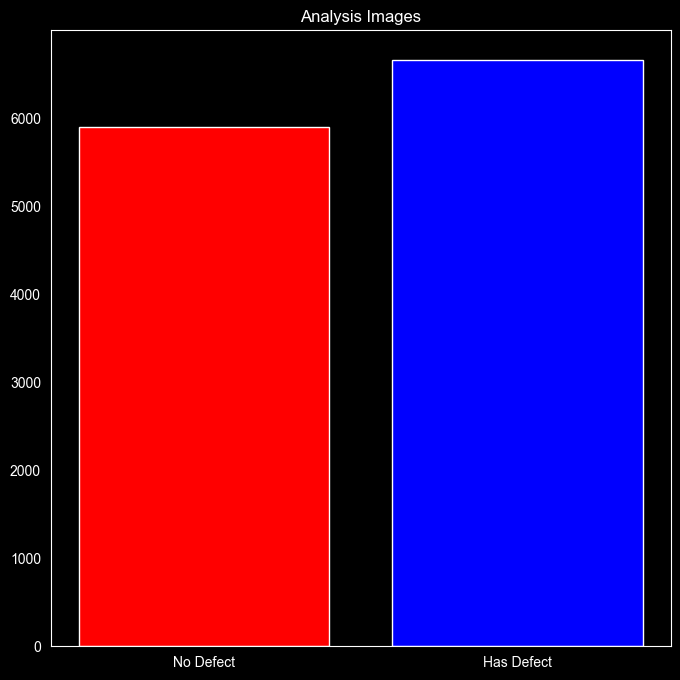

In [6]:
# Get all images from training Image
all_images = os.listdir(TRAIN_DIR)
all_images = [img for img in all_images if img.endswith((".jpg", ".png"))]

# Image id from csv
defect_images = df["ImageId"].unique().tolist()

# Image no defect
no_defect_images = set(all_images) - set(defect_images)

print("The number of all images is ", len(all_images))
print("The number of all images with defect ", len(defect_images))
print("The number of all images without defect ", len(no_defect_images))

# Bar plot
plt.figure(figsize=(8, 8))
plt.bar(["No Defect", "Has Defect"], [len(no_defect_images), len(defect_images)], color=["red", "blue"])
plt.title("Analysis Images")
plt.grid(False)
plt.show()

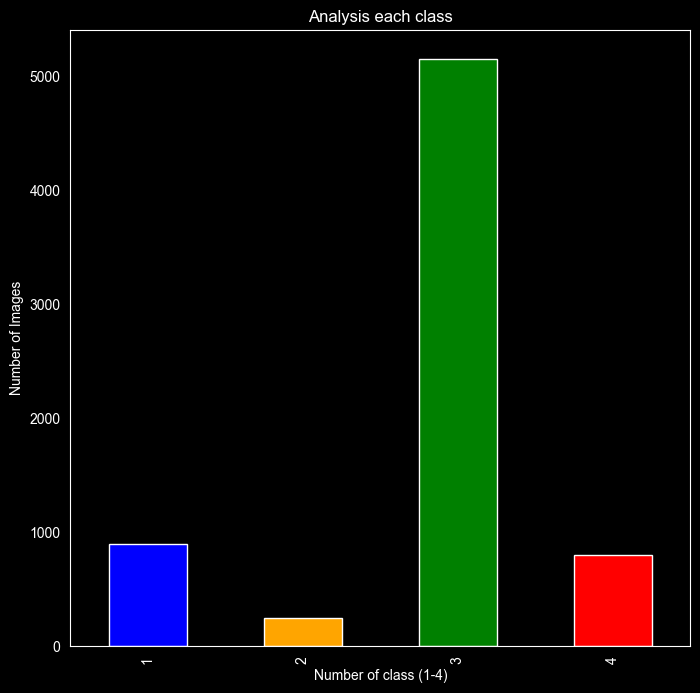

In [7]:
class_counts = (df[df["EncodedPixels"].notnull()].groupby("ClassId")["ImageId"].nunique())

# Total samples
total_images = df["ImageId"].nunique()
plt.figure(figsize=(8,8))
class_counts.plot(kind="bar", color=["blue","orange","green","red"])
plt.title("Analysis each class")
plt.ylabel("Number of Images")
plt.xlabel("Number of class (1-4)")
plt.grid(False)
plt.show()

### Preprocessing

In [8]:
class RLEprocessor:
    """RLE encoding and decoding"""

    @staticmethod
    def rle_decoder(rle_str, shape=(CONFIG['Height'], CONFIG['Width'])) -> np.ndarray:
        rle_list = rle_str.split()  # convert to list
        assert isinstance(rle_list, list)  # if is list, be passed
        start, length = [np.asarray(x, dtype=int) for x in (rle_list[0::2], rle_list[1::2])]
        # start = [rle_list[x] - 1 for x in range(0, len(rle_list), 2)]
        # length = [rle_list[x] for x in range(1, len(rle_list), 2)]
        start -= 1
        ends = start + length
        image = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for start, end in zip(start, ends):
            image[start:end] = 1
        return image.reshape(shape, order='F')

    @staticmethod
    def build_masks(df: pd.DataFrame, image_id: str) -> np.ndarray:
        mask = np.zeros((CONFIG["Height"], CONFIG['Width'], CONFIG['n_classes']), dtype=np.uint8)

        for i in range(1, 5):
            rle = df.loc[
                (df["ImageId"] == image_id) & (df['ClassId']== i), "EncodedPixels"
            ]
            if len(rle) > 0:
                rle = rle.values[0]
                if pd.notna(rle):
                    mask[:,:, i-1] = RLEprocessor.rle_decoder(rle)
        return mask

    @staticmethod
    def rle_encoder(mask):
        pixels = mask.T.flatten(order='F')
        pixels = np.concatenate([[0], pixels, [0]])
        runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Use 0 to covert tuple to nparray
        runs[1::2] -= runs[::2]
        return ' '.join(str(x) for x in runs)

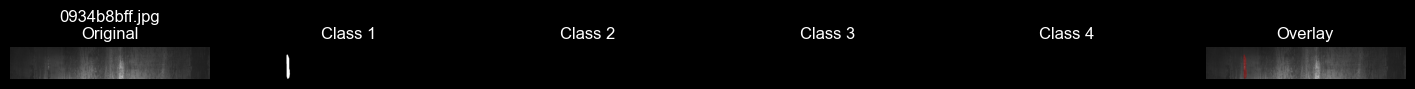

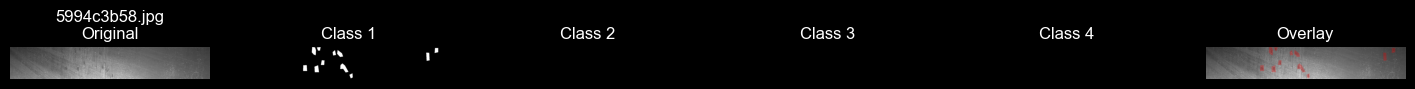

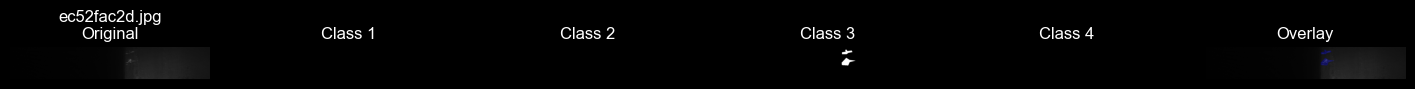

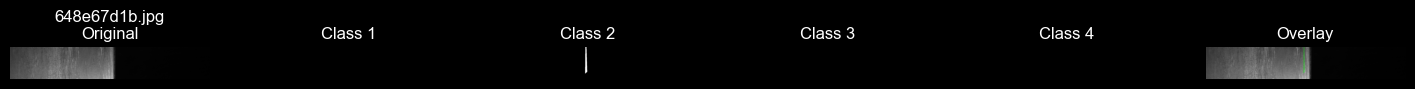

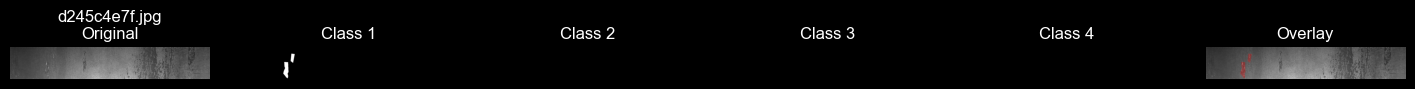

In [9]:
sample_images = df["ImageId"].drop_duplicates().sample(5, random_state=42).tolist()

for image_id in sample_images:
    img_path = TRAIN_DIR / image_id
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    masks = RLEprocessor.build_masks(df, image_id)

    plt.figure(figsize=(18,4))
    plt.subplot(1,6,1)
    plt.imshow(img)
    plt.title(f"{image_id}\nOriginal")
    plt.axis("off")

    # Sınıf maskeleri
    for i in range(4):
        plt.subplot(1,6,i+2)
        plt.imshow(masks[..., i], cmap="gray")
        plt.title(f"Class {i+1}")
        plt.axis("off")

    # Overlay
    overlay = img.copy()
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0)]  # R, G, B, Sarı
    for i in range(4):
        mask = masks[..., i].astype(bool)
        overlay[mask] = (0.7*overlay[mask] + 0.3*np.array(colors[i])).astype(np.uint8)

    plt.subplot(1,6,6)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

### Augmentation

In [10]:
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9,1.1), translate_percent=(0.02,0.02), rotate=(-5,5), p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        A.RandomBrightnessContrast(p=0.4),
        A.Resize(CONFIG['Height'], CONFIG["Width"], interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ], is_check_shapes=False)
val_transform = A.Compose([
        A.Resize(CONFIG['Height'], CONFIG["Width"], interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

### Build data

In [11]:
class SteverstalDataset(Dataset):
    """PyTorch Dataset for Severstal"""

    def __init__(self, image_ids, df: pd.DataFrame, image_dir, transform=None, load_rgb=True):
        self.df = df
        self.image_dir = Path(image_dir)
        self.image_ids= list(image_ids)
        self.transform = transform
        self.load_rgb = load_rgb

    def __len__(self):
        return len(self.image_ids)

    def _read_image(self, image_id):
        img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found: {image_id}")
        if self.load_rgb:
            img = np.repeat(img[..., None], 3, axis=2)  # (H,W,3)
        return img


    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = self._read_image(image_id)
        mask = RLEprocessor.build_masks(self.df, image_id)

        if self.transform:
            output = self.transform(image=image, mask=mask)
            image, mask = output['image'], output['mask'].permute(2, 0, 1) # (C, H, W)
        else:
            image = torch.from_numpy(image.transpose(2,0,1)).float()
            mask = torch.from_numpy(mask.transpose(2,0,1)).float()

        meta = {"image_id": image_id}
        return {
            'image': image,   # (3, H, W)
            'mask': mask,     # (4, H, W)
            'image_id': image_id
        }


# --- Collate function ---
def collate_fn(batch):
    images, masks, metas = zip(*batch)
    images = torch.stack(images)
    masks = torch.stack(masks)
    return images, masks, metas

### Dataset , Dataloader

In [12]:
train_ids, valid_ids = train_test_split(
    df["ImageId"].unique(),
    test_size=CONFIG["val_split"],
    random_state=CONFIG["Seed"]
)

In [13]:
train_ds = SteverstalDataset(train_ids, df, TRAIN_DIR, transform=train_transform)
val_ds = SteverstalDataset(valid_ids, df, TRAIN_DIR, transform=val_transform)

In [14]:
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

In [15]:
batch = next(iter(train_loader))

In [16]:
images = batch['image']

In [17]:
images.shape[0]

8

In [18]:
images.shape

torch.Size([8, 3, 256, 1600])

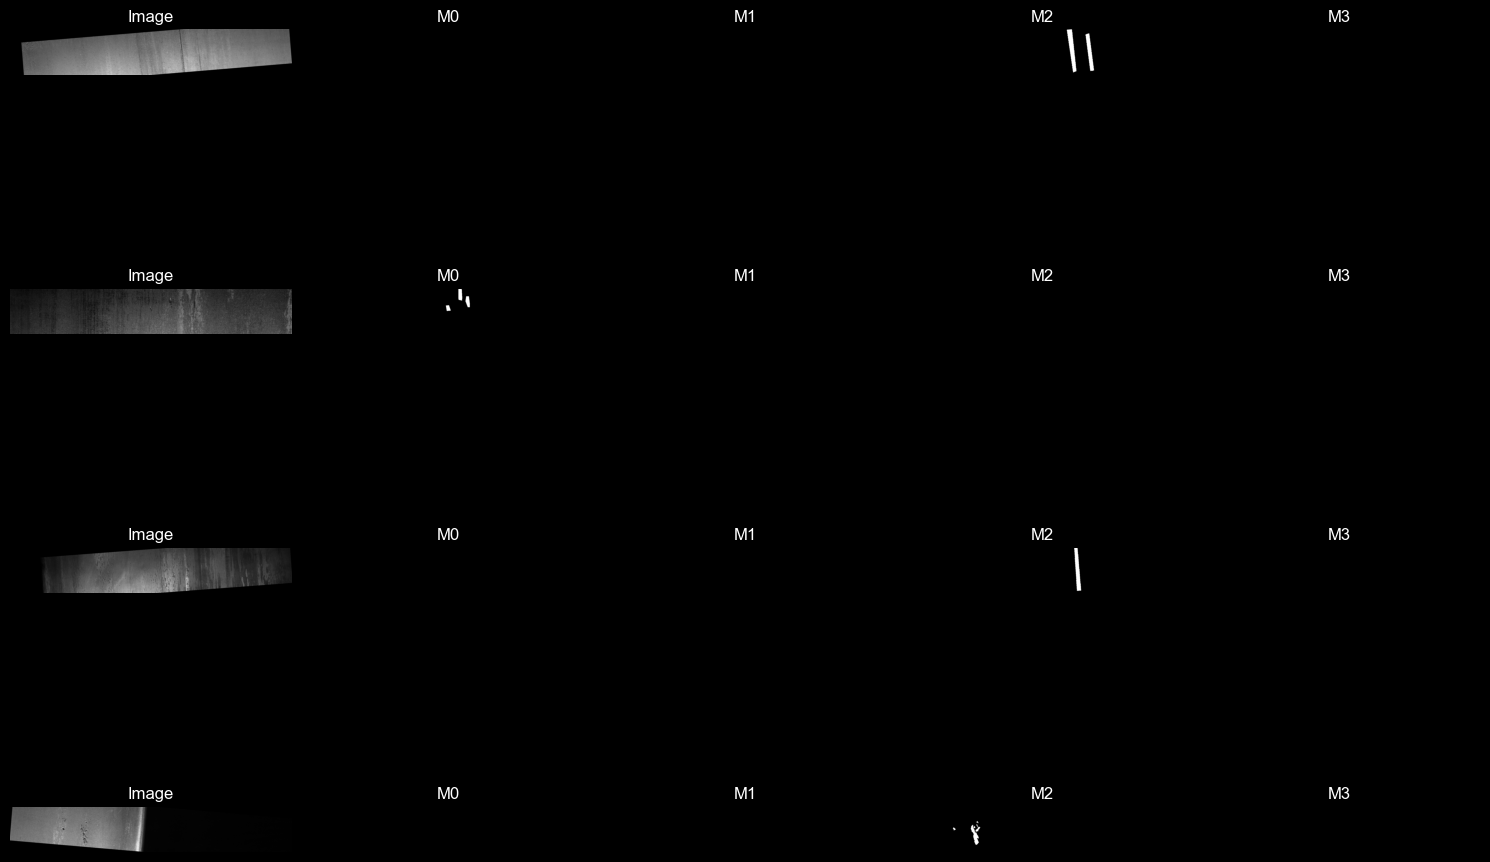

In [19]:
batch = next(iter(train_loader))
images = batch['image']
masks = batch['mask']
B = images.shape[0]  # batch size
num_show = min(4, B)  # hiển thị tối đa 4 sample

plt.figure(figsize=(15, 3 * num_show))

for i in range(num_show):
    img = images[i].cpu().numpy()[0]   # (H, W)
    mask = masks[i].cpu().numpy()      # (4, H, W)
    #print(mask[i])

    # unnormalize nếu cần
    img = (img * 0.5) + 0.5

    # ===== Image =====
    plt.subplot(num_show, 5, i*5 + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Image")
    plt.axis('off')

    # ===== 4 Masks =====
    for j in range(4):
        plt.subplot(num_show, 5, i*5 + 2 + j)
        plt.imshow(mask[j,:,:], cmap='gray')
        plt.title(f"M{j}")
        plt.axis('off')

plt.tight_layout()
plt.show()

## Model

In [20]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv_block(x)

# class Encoder(nn.Module):
#     def __init__(self, in_channels, out_channels, kernel_size, padding):
#         super().__init__()
#         self.encoder = nn.Sequential(
#             nn.MaxPool2d(kernel_size=2),
#             ConvBlock(in_channels, out_channels, kernel_size, padding),
#         )
#     def forward(self, x):
#         return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, in_channels, mid_channels, out_channels, kernel_size, padding, bilinear=True):
        super().__init__()
        if bilinear:
            self.conv_trans = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv_block = ConvBlock(mid_channels, out_channels, kernel_size, padding)
        else:
            self.conv_trans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv_block = ConvBlock(mid_channels, out_channels, kernel_size, padding)

    def forward(self, x1, x2):
        # B, C, H, W
        x1= self.conv_trans(x1)
        # print(x1.shape)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, (diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2))
        x = torch.cat([x2, x1], dim=1) # concat by channel
        return self.conv_block(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        return self.conv(x)


In [21]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

class EfficientUNetB4(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super().__init__()
        weights = EfficientNet_B4_Weights.IMAGENET1K_V1
        self.encoder = efficientnet_b4(weights=weights).features

        # Cắt mạng EfficientNet thành các khối (blocks) dựa theo độ giảm không gian
        # stage 0: (Block 0->1)  - Không gian 1/2, 24 channels
        # stage 1: (Block 2)     - Không gian 1/4, 32 channels
        # stage 2: (Block 3)     - Không gian 1/8, 56 channels
        # stage 3: (Block 4->5)  - Không gian 1/16, 160 channels
        # stage 4: (Block 6->7)  - Không gian 1/32, 448 channels

        self.enc_stage0 = self.encoder[0:2]
        self.enc_stage1 = self.encoder[2:3]
        self.enc_stage2 = self.encoder[3:4]
        self.enc_stage3 = self.encoder[4:6]
        self.enc_stage4 = self.encoder[6:8]

        factor = 2 if bilinear else 1
        self.bottom_neck = ConvBlock(448//factor, 448//factor, kernel_size=1, padding=0)
        self.up1 = Decoder(448, 160, 256//factor, 3, 1, bilinear=bilinear)
        self.up2 = Decoder(256, 56, 128//factor, 3, 1, bilinear=bilinear)
        self.up3 = Decoder(128, 32, 64//factor, 3, 1, bilinear=bilinear)
        self.up4 = Decoder(64, 24, 32, 3, 1, bilinear=bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        # Encoder
        x1 = self.enc_stage0(x)
        x2 = self.enc_stage1(x1)
        x3 = self.enc_stage2(x2)
        x4 = self.enc_stage3(x3)
        x5 = self.enc_stage4(x4)

        # Bottom neck
        x5 = self.bottom_neck(x5) # 448

        # Decoder
        x = self.up1(x5, x4) # 256
        x = self.up2(x, x3) # 128
        x = self.up3(x, x2) # 64
        out = self.up4(x, x1) # 32
        return self.outc(out) # 4

In [27]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super(DecoderBlock, self).__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # Tích chập kết hợp đặc trưng upsample và skip connection
        self.conv1 = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            # Nối (concatenate) đặc trưng từ nhánh giải mã và nhánh mã hóa
            x = torch.cat([x, skip], dim=1)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class EfficientUNetB4(nn.Module):
    def __init__(self, num_classes=1):
        super(EfficientUNetB4, self).__init__()

        # 1. Khởi tạo EfficientNet-B4 với trọng số pre-train ImageNet
        weights = EfficientNet_B4_Weights.IMAGENET1K_V1
        self.encoder = efficientnet_b4(weights=weights).features

        # Cắt mạng EfficientNet thành các khối (blocks) dựa theo độ giảm không gian
        # stage 0: (Block 0->1)  - Không gian 1/2, 24 channels
        # stage 1: (Block 2)     - Không gian 1/4, 32 channels
        # stage 2: (Block 3)     - Không gian 1/8, 56 channels
        # stage 3: (Block 4->5)  - Không gian 1/16, 160 channels
        # stage 4: (Block 6->7)  - Không gian 1/32, 448 channels

        self.enc_stage0 = self.encoder[0:2]
        self.enc_stage1 = self.encoder[2:3]
        self.enc_stage2 = self.encoder[3:4]
        self.enc_stage3 = self.encoder[4:6]
        self.enc_stage4 = self.encoder[6:8]

        # 2. Xây dựng Decoder (Nhánh giải mã)
        self.dec_stage4 = DecoderBlock(in_channels=448, skip_channels=160, out_channels=256) # Khôi phục 1/16
        self.dec_stage3 = DecoderBlock(in_channels=256, skip_channels=56, out_channels=128)  # Khôi phục 1/8
        self.dec_stage2 = DecoderBlock(in_channels=128, skip_channels=32, out_channels=64)   # Khôi phục 1/4
        self.dec_stage1 = DecoderBlock(in_channels=64, skip_channels=24, out_channels=32)    # Khôi phục 1/2
        self.dec_stage0 = DecoderBlock(in_channels=32, skip_channels=0, out_channels=16)     # Khôi phục 1/1

        # Lớp đầu ra để trả về mặt nạ khuyết tật
        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        # MÃ HÓA (ENCODER)
        e0 = self.enc_stage0(x)     # Lấy skip 1
        e1 = self.enc_stage1(e0)    # Lấy skip 2
        e2 = self.enc_stage2(e1)    # Lấy skip 3
        e3 = self.enc_stage3(e2)    # Lấy skip 4
        e4 = self.enc_stage4(e3)    # Điểm thắt cổ chai (bottleneck)

        # GIẢI MÃ (DECODER)
        d4 = self.dec_stage4(e4, e3)
        d3 = self.dec_stage3(d4, e2)
        d2 = self.dec_stage2(d3, e1)
        d1 = self.dec_stage1(d2, e0)
        d0 = self.dec_stage0(d1)    # Tầng cuối lên bằng kích thước ảnh gốc, không dùng skip

        out = self.final_conv(d0)
        return out

In [28]:
model = EfficientUNetB4(4)

In [29]:
from torchinfo import summary
summary(model, input_size=(8, 3, 256, 1600))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientUNetB4                                         [8, 4, 256, 1600]         806,400
├─Sequential: 1-1                                       [8, 24, 128, 800]         --
│    └─Conv2dNormActivation: 2-1                        [8, 48, 128, 800]         --
│    │    └─Conv2d: 3-1                                 [8, 48, 128, 800]         1,296
│    │    └─BatchNorm2d: 3-2                            [8, 48, 128, 800]         96
│    │    └─SiLU: 3-3                                   [8, 48, 128, 800]         --
│    └─Sequential: 2-2                                  [8, 24, 128, 800]         --
│    │    └─MBConv: 3-4                                 [8, 24, 128, 800]         2,940
│    │    └─MBConv: 3-5                                 [8, 24, 128, 800]         1,206
├─Sequential: 1-2                                       [8, 32, 64, 400]          --
│    └─Sequential: 2-3                        

## Metrics

In [24]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): super().__init__(); self.smooth=smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        p = probs.view(probs.size(0), probs.size(1), -1)
        t = targets.view(targets.size(0), targets.size(1), -1)
        inter = (p*t).sum(2); den = p.sum(2)+t.sum(2)
        dice = (2*inter + self.smooth) / (den + self.smooth)
        return 1.0 - dice.mean()

class WeightedFocalDiceLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, lam_f=0.7, lam_d=0.3):
        super().__init__()
        self.w = class_weights
        self.g = gamma
        self.lf = lam_f
        self.ld = lam_d
        self.dice = DiceLoss()

    def forward(self, logits, targets, return_details=False):
        probs = torch.sigmoid(logits)
        eps = 1e-8

        # BCE
        bce = -(targets * torch.log(probs + eps) +
                (1 - targets) * torch.log(1 - probs + eps))

        # Focal loss
        pt = torch.where(targets == 1, probs, 1 - probs)
        fw = (1 - pt) ** self.g

        if self.w is not None:
            fw = fw * logits.new_tensor(self.w).view(1, -1, 1, 1)

        focal = (fw * bce).mean()
        dice = self.dice(logits, targets)

        loss = self.lf * focal + self.ld * dice

        if return_details:
            return loss, {"focal": focal.item(), "dice": dice.item()}
        return loss

@torch.no_grad()
def dice_coefficient(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((2,3)); den = preds.sum((2,3))+targets.sum((2,3))
    dice = (2*inter+eps)/(den+eps)
    return dice.mean()

@torch.no_grad()
def dice_per_class(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((0,2,3)); den = preds.sum((0,2,3))+targets.sum((0,2,3))
    return ((2*inter+eps)/(den+eps)).cpu().tolist()

## Training

In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.to(device)
    model.train()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for batch in tqdm(loader, desc="Train", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        bs = imgs.size(0)
        n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(outputs, masks).item() * bs
    return {"loss": run_loss / n, "dice": run_dice / n}

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.to(device)
    model.eval()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for batch in tqdm(loader, desc="Valid", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].to(device)
        out = model(imgs)
        loss = criterion(out, masks)
        bs = imgs.size(0); n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(out, masks).item() * bs
    return {"loss": run_loss/n, "dice": run_dice/n}


In [27]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=CONFIG["epochs"],save_path="best_model.pth"):
    best_dice = -1.0
    history = {"train": [],
               "valid": []}
    for epoch in range(1, num_epochs+1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        # all_val_dice = []
        # for imgs, masks, _ in val_loader:
        #     imgs, masks = imgs.to(device), masks.to(device)
        #     outputs = model(imgs)
        #     all_val_dice.append(dice_per_class(outputs, masks))
        # val_metrics["per_class_dice"] = np.mean(all_val_dice, axis=0).tolist()

        print(f"Train Loss: {train_metrics['loss']:.4f}, Dice: {train_metrics['dice']:.4f}")
        print(f"Valid Loss: {val_metrics['loss']:.4f}, Dice: {val_metrics['dice']:.4f}")

        history["train"].append({**train_metrics, "lr": optimizer.param_groups[0]["lr"]})
        history["valid"].append(val_metrics)

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), save_path)
            print(f"Best model saved at epoch {epoch} (dice={best_dice:.4f})")

    print(f"Training finished. Best Dice = {best_dice:.4f}")
    return history


In [28]:
model = Eff_UNet(n_channels=CONFIG["n_channels"], n_classes=CONFIG["n_classes"])
criterion = WeightedFocalDiceLoss(class_weights=[0.12,0.03,0.72,0.11])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [ ]:
history = fit(model, train_loader, val_loader, optimizer, criterion, device, CONFIG['epochs'])

### Visualization

In [ ]:
def plot_history(history, out_dir=WORK_DIR, show=True):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure()
    plt.plot(tr_d, label="Train")
    plt.plot(va_d, label="Valid")
    plt.title("Dice Score")
    plt.legend()
    plt.savefig(out_dir / "dice_curve.png")
    if show: plt.show()
    plt.close()

    # Loss
    plt.figure()
    plt.plot(tr_l, label="Train")
    plt.plot(va_l, label="Valid")
    plt.title("Loss")
    plt.legend()
    plt.savefig(out_dir / "loss_curve.png")
    if show: plt.show()
    plt.close()

    # Learning Rate
    plt.figure()
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.legend()
    plt.savefig(out_dir / "lr_curve.png")
    if show: plt.show()
    plt.close()

# 1) Vẽ biểu đồ quá trình huấn luyện
def plot_training_curves(history, out_dir=WORK_DIR):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure(figsize=(6,4))
    plt.plot(tr_d, label="Train Dice")
    plt.plot(va_d, label="Valid Dice")
    plt.title("Dice Score")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"dice_curve.png")
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(tr_l, label="Train Loss")
    plt.plot(va_l, label="Valid Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"loss_curve.png")
    plt.show()

    # LR
    plt.figure(figsize=(6,4))
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True)
    plt.savefig(out_dir/"lr_curve.png")
    plt.show()

# 2) Dice score theo từng lớp
@torch.no_grad()
def plot_per_class_dice(model, loader, device, class_names=None):
    model.to(device)
    model.eval()
    dices = []
    for batch in loader:
        imgs = batch["image"].to(device)
        masks = batch["mask"].to(device)
        logits = model(imgs)
        dices.append(dice_per_class(logits, masks))

    dices = np.array(dices).mean(0)
    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(len(dices))]

    plt.figure(figsize=(6,4))
    plt.bar(class_names, dices, color=["blue","orange","green","red"])
    plt.title("Per-Class Dice Scores")
    plt.ylabel("Dice")
    plt.ylim(0,1)
    plt.grid(True, axis="y")
    plt.show()

# # 3) Trực quan hóa dự đoán mẫu
# @torch.no_grad()
# def visualize_predictions(model, dataset, device, k=3, thr=CFG["THRESHOLD"]):
#     model.eval()
#     idxs = np.random.choice(len(dataset), size=min(k,len(dataset)), replace=False)
#     for i in idxs:
#         img, mask, meta = dataset[i]
#         x = img.unsqueeze(0).to(device)
#         pred = torch.sigmoid(model(x))[0].cpu().numpy().transpose(1,2,0)
#         pred_bin = (pred > thr).astype(np.uint8)
#
#         img_np  = img.permute(1,2,0).numpy()
#         mask_np = mask.permute(1,2,0).numpy()
#
#         fig, axs = plt.subplots(1,3,figsize=(15,5))
#         axs[0].imshow((img_np-img_np.min())/(img_np.max()-img_np.min()+1e-8))
#         axs[0].set_title(meta["image_id"]); axs[0].axis("off")
#
#         axs[1].imshow(mask_np.max(-1), cmap="gray")
#         axs[1].set_title("Ground Truth"); axs[1].axis("off")
#
#         axs[2].imshow(pred_bin.max(-1), cmap="gray")
#         axs[2].set_title("Prediction"); axs[2].axis("off")
#         plt.show()